In [4]:
import numpy as np
import pandas as pd
import json
import scipy
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize

msize=12
mwidth = 2
fsize=16
alpha=0.3
lsize = 2
framewidth = 3
markeredgewidth=3
markeredgewidth_no=10

colors = [
         "mediumslateblue", "rebeccapurple", "darkorchid", 
         "violet", "orchid", "magenta", "deeppink","green","limegreen","darkorange", "dodgerblue",
         "deepskyblue", "black", "grey",
         
         ]

In [5]:
names = ["propanol","butanol","carbondioxide","water", "water_new2", "butane", "hexane"]

names = ["propane", "butane", "hexane",
         "heptane", "octane", "nonane", "dodecane",
         "propanol","butanol","carbondioxide", "water", 
         "water_hbond", "water_hbond_fix"
         ]


#names = ["propanol","butanol","propane","butane","hexane", "heptane", "octane","nonane","dodecane"]

savepath = "free_volume_aiaiai/"

try:
    os.mkdir(savepath)
except:
    None


In [6]:
datas = []
for name in names:
    ppath = "experimental/"+name+"/"+name+"_viscosity_proc.csv"
    # if os.path.exists(ppath):
    data = pd.read_csv(ppath)
    data = data[  data["s_res"] < -8  ] # exclude not converged (iG) datapoints
    data = data[  data["pressure"] < 2e8  ]
    print("lload")    
    datas.append(data)

lload
lload
lload
lload
lload
lload
lload
lload
lload
lload
lload
lload
lload


In [7]:
poly_dict = {
    "propane": [3.51848530e+00,  8.98719202e-01, -6.57541675e-02,  4.85748207e-03,
       -3.89815685e-02,  3.23990347e-04,  2.68096625e-05],
    "butane": [2.93675606e+00,  6.58606541e-01, -3.54757854e-02,  3.43297168e-03,
       -2.34423967e-02, -3.20780717e-09,  2.77658981e-06],
    "hexane": [  3.201e+00 , 6.538e-01, -2.872e-02,  2.056e-03, -3.439e-02, -2.500e-09 , 9.602e-06],
    "heptane": [3.14259960e+00,  5.87862794e-01, -2.91491603e-02,  2.08778638e-03,
       -1.44664705e-02, -1.24873294e-19, -1.24873294e-19],
    "octane": [ 3.26730119e+00,  6.05701436e-01, -2.67738775e-02,  1.79895834e-03,
       -2.85554249e-02, -8.00307969e-19, -8.00307969e-19],
    "nonane": [ 3.25593263e+00,  5.94314410e-01, -3.34719291e-02,  2.06303415e-03,
       -1.34864713e-02, -7.79506607e-19, -7.79506607e-19],
    "dodecane": [ 3.14613724e+00,  4.33415774e-01, -1.43774533e-02,  8.43063298e-04,
        6.78612430e-03, -9.35159214e-05, -4.08358569e-06 ],
    "propanol":[3.1066556182709726, 0.3339730333762955, 0.009245313934974447, 0.0013849394768765822, -0.047430508899753754, -0.0005883123087159559, -3.303476589905937e-05],
    "butanol": [ 3.09736418e+00,  5.16332669e-01, -1.12147937e-02,  1.86113048e-03,
        -9.89413889e-02,  1.41800551e-07,  2.59356047e-06],
     "carbondioxide": [ 2.43423933e+00,  1.00134140e-01,  9.41409197e-02, -5.46421374e-03,
        8.63269060e-02, -1.07508664e-02,  4.90355962e-04],
     "water": [ 4.02290363e+00,  3.74513465e-01, -1.00705969e-01,  2.27679907e-03,
        1.80066136e-01,  7.67372189e-03,  5.27146621e-05],
    "water_new2": [4.03210064e+00,  3.71941896e-01, -1.03863165e-01,  2.68905680e-03,
        1.76920251e-01,  8.88540130e-03,  9.45182114e-07],      
    "water_hbond": [4.14071517e+00,  3.08348513e-01, -6.26207933e-02,  5.13599738e-03,
        1.60000000e-01,  8.43927589e-06,  1.00000000e-04],
    "water_hbond_fix":[ 4.17987307e+00,  2.73614916e-01, -9.99996458e-02,  1.30869622e-02, 0, 0, 0 ],
}



In [8]:
x = np.linspace(1,10,100)
for key in names:
    p = poly_dict[key]#[::-1] +[0]

    kk = key.split("_")
    nn = kk[0]
    print_list = [nn]+[ str(round(x,3)) for x in poly_dict[key] ]
    print( " & ".join(print_list) + " \\\\" )

propane & 3.518 & 0.899 & -0.066 & 0.005 & -0.039 & 0.0 & 0.0 \\
butane & 2.937 & 0.659 & -0.035 & 0.003 & -0.023 & -0.0 & 0.0 \\
hexane & 3.201 & 0.654 & -0.029 & 0.002 & -0.034 & -0.0 & 0.0 \\
heptane & 3.143 & 0.588 & -0.029 & 0.002 & -0.014 & -0.0 & -0.0 \\
octane & 3.267 & 0.606 & -0.027 & 0.002 & -0.029 & -0.0 & -0.0 \\
nonane & 3.256 & 0.594 & -0.033 & 0.002 & -0.013 & -0.0 & -0.0 \\
dodecane & 3.146 & 0.433 & -0.014 & 0.001 & 0.007 & -0.0 & -0.0 \\
propanol & 3.107 & 0.334 & 0.009 & 0.001 & -0.047 & -0.001 & -0.0 \\
butanol & 3.097 & 0.516 & -0.011 & 0.002 & -0.099 & 0.0 & 0.0 \\
carbondioxide & 2.434 & 0.1 & 0.094 & -0.005 & 0.086 & -0.011 & 0.0 \\
water & 4.023 & 0.375 & -0.101 & 0.002 & 0.18 & 0.008 & 0.0 \\
water & 4.141 & 0.308 & -0.063 & 0.005 & 0.16 & 0.0 & 0.0 \\
water & 4.18 & 0.274 & -0.1 & 0.013 & 0 & 0 & 0 \\


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

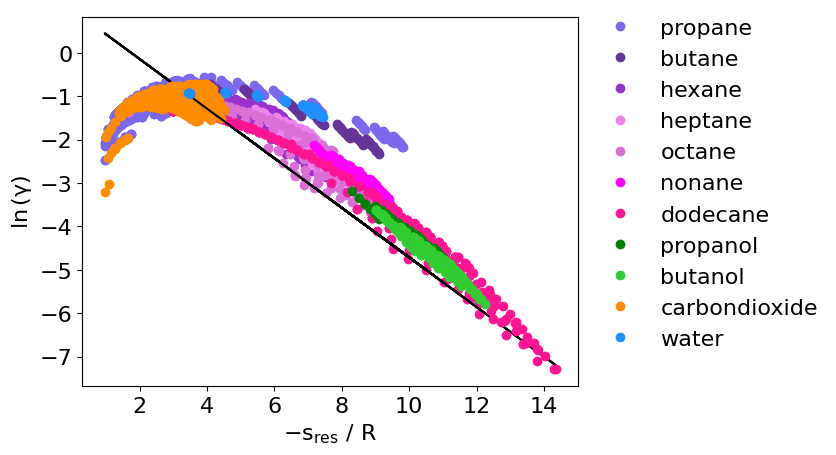

In [12]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]
    x = -data["s_res"]/8.314 

    ln_gamma = data["s_res"]/8.314 - np.log( 16 ) + 3*np.log( -data["E_res"]/8.314 /data["temperature"] ) 
    gamma = np.exp(ln_gamma)
    yy = 1 -8/14 *  -data["s_res"] /8.314 

    if not "_" in name:
        plt.plot( x, yy, "k"  )
        plt.plot( x, ln_gamma, ".", label=name,color=color ,markersize=msize  )



plt.ylabel(r"$ \ln{(\gamma)}$",fontsize=fsize)
plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"gamma.png",bbox_inches='tight')
plt.savefig(savepath+"gamma.pdf",bbox_inches='tight')

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.05))


plt.savefig(savepath+"gamma_legend.png",bbox_inches='tight')
plt.savefig(savepath+"gamma_legend.pdf",bbox_inches='tight')

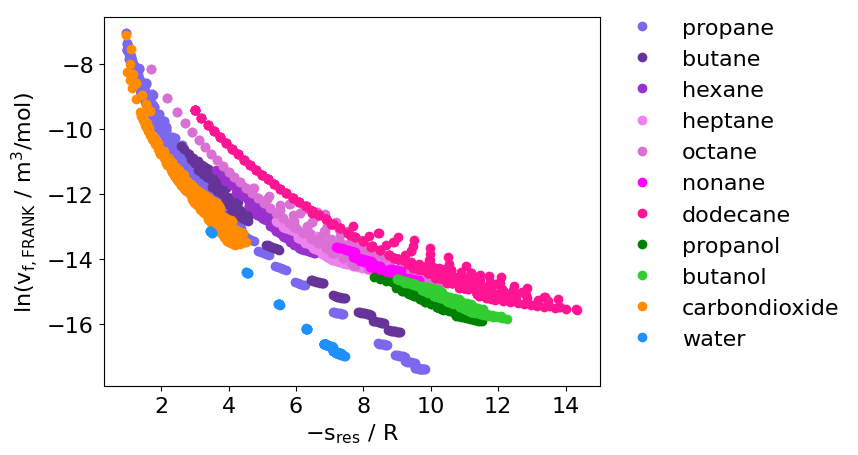

In [14]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]

    x = -data["s_res"]/8.314 

    ln_vf = + np.log( 16*data["V"] ) - 3*np.log( -data["E_res"]/8.314 /data["temperature"] ) 

    if not "_" in name:
        plt.plot( x, ln_vf, ".", label=name,color=color ,markersize=msize  )


plt.ylabel(r"$\ln(v_{f,\text{FRANK} }~/~m^3/mol)$",fontsize=fsize)
plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"vf_frank.png",bbox_inches='tight')
plt.savefig(savepath+"vf_frank.pdf",bbox_inches='tight')

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.05))


plt.savefig(savepath+"vf_frank_legend.png",bbox_inches='tight')
plt.savefig(savepath+"vf_frank_legend.pdf",bbox_inches='tight')


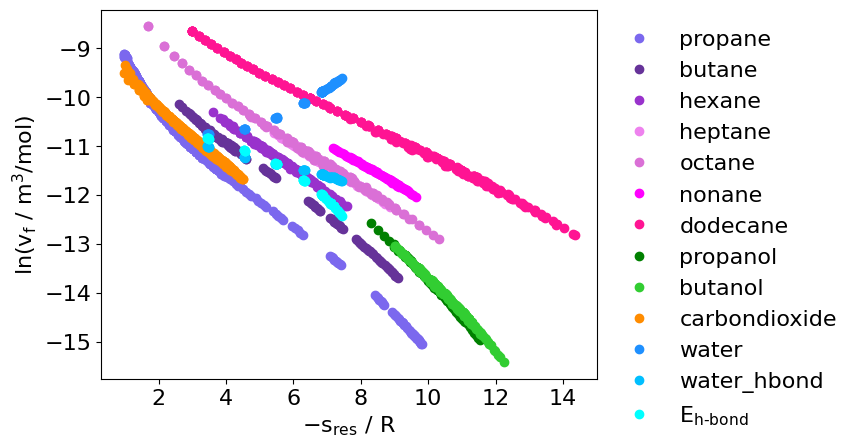

In [27]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]
    p = poly_dict[name]
    x = -data["s_res"]/8.314
    #xx = p[2]*x + p[3]*x*x + p[4]*x*x*x
    xx = p[1]*x + p[2]*x*x + p[3]*x*x*x
    vf = np.log(data["V"]) - 3/4*xx #* np.exp(xx)
    if name == "water_hbond_fix":
        plt.plot( x, vf, ".", label=r"$E_\text{h-bond}$" ,color="aqua" ,markersize=msize )
    else:
        plt.plot( x, vf, ".", label=name, color=color ,markersize=msize )
    #plt.plot( x, vf, ".", label=name, color=color ,markersize=msize )
    #plt.plot( x, np.log(data["V"]), "x", label=name, color=color ,markersize=msize )

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(v_f~/~m^3/mol)$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"log_vf.png",bbox_inches='tight')
plt.savefig(savepath+"log_vf.pdf",bbox_inches='tight')

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.0))


plt.savefig(savepath+"log_vf_legend.png",bbox_inches='tight')
plt.savefig(savepath+"log_vf_legend.pdf",bbox_inches='tight')

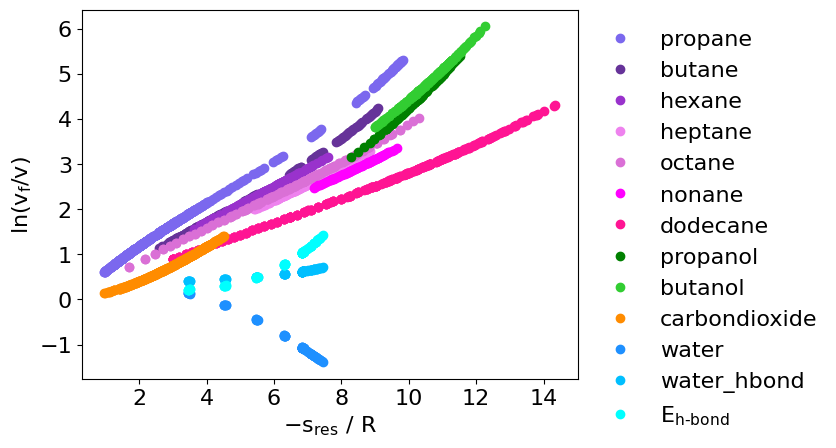

In [28]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]
    p = poly_dict[name]
    x = -data["s_res"]/8.314
    #xx = p[2]*x + p[3]*x*x + p[4]*x*x*x
    xx = p[1]*x + p[2]*x*x + p[3]*x*x*x
    vvf =  3/4* xx #* np.exp(xx)
    if name == "water_hbond_fix":
        plt.plot( x, vvf, ".", label=r"$E_\text{h-bond}$" ,color="aqua" ,markersize=msize )
    else:
        plt.plot( x, vvf, ".", label=name, color=color ,markersize=msize )
    #plt.plot( x, vf, ".", label=name, color=color ,markersize=msize )


plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln( v_f / v )$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"log_vvf.png",bbox_inches='tight')
plt.savefig(savepath+"log_vvf.pdf",bbox_inches='tight')

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.0))


plt.savefig(savepath+"log_vvf_legend.png",bbox_inches='tight')
plt.savefig(savepath+"log_vvf_legend.pdf",bbox_inches='tight')

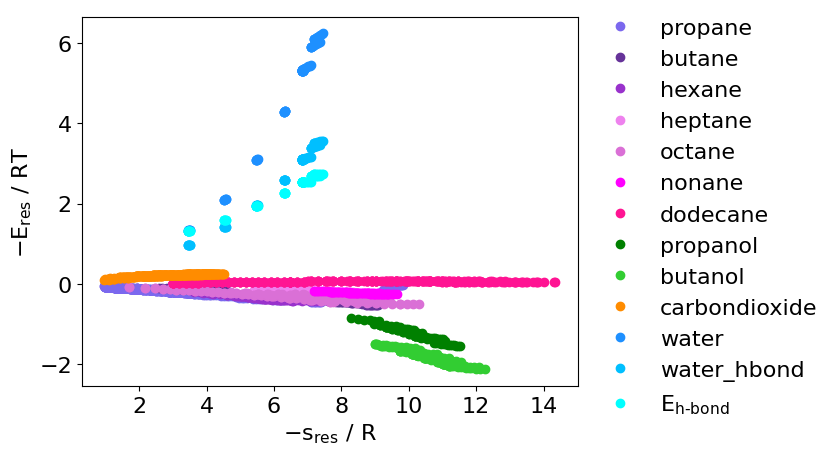

In [30]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]
    p = poly_dict[name]
    x = -data["E_res"]/8.314/data["temperature"]
    xx = p[4]*x + p[5]*x*x + p[6]*x*x*x

    x = -data["s_res"]/8.314
    if name != "water_hbond_fix":
        plt.plot( x, xx, ".", label=name,color=color ,markersize=msize  )

xx = 6.3*1000 / 8.314/data["temperature"]
plt.plot( x, xx, ".", label=r"$E_\text{h-bond}$" ,color="aqua" ,markersize=msize )



plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$-E_\text{res}~/~RT$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"activation_energy.png",bbox_inches='tight')
plt.savefig(savepath+"activation_energy.pdf",bbox_inches='tight')

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.05))


plt.savefig(savepath+"activation_energy_legend.png",bbox_inches='tight')
plt.savefig(savepath+"activation_energy_legend.pdf",bbox_inches='tight')



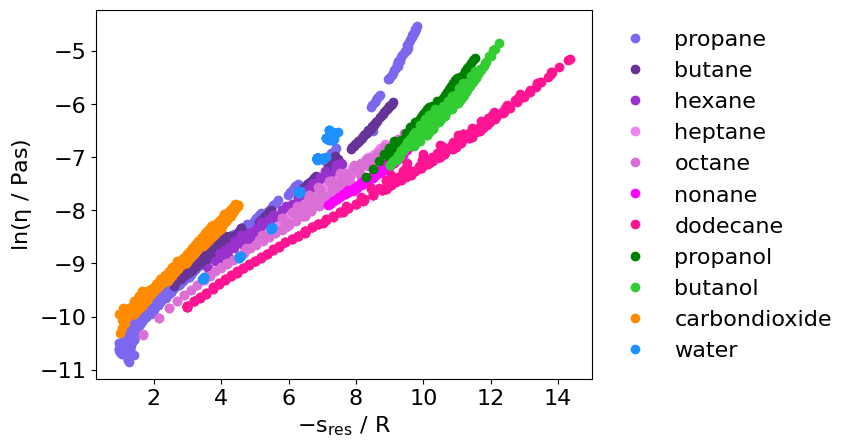

In [32]:
for i,name in enumerate(names):
    data = datas[i]
    color = colors[i]
    p = poly_dict[name]
    x = -data["s_res"]/8.314
    if not "water_hbond" in name:
        plt.plot( x, np.log( data["viscosity"] ), ".", label=name, color=color ,markersize=msize )

plt.legend(fontsize=fsize,frameon=False,bbox_to_anchor=(1.0,1.0))

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln( \eta~/~Pas)$",fontsize=fsize)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"log_eta_exp.png",bbox_inches='tight')
plt.savefig(savepath+"log_eta_exp.pdf",bbox_inches='tight')